# Data Cleaning
## Import Required Packages

In [1]:
import os                                               
import random                                              
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight

random.seed(42)
np.random.seed(42)

## Define Path where Data is located

In [2]:
DATA_DIR  = Path("../data/PlantVillage")        #path for downloaded images
CLEAN_DIR = Path("../data/PlantVillage_split")  #path to save images that are splitted

assert DATA_DIR.exists(), f"Cannot find {DATA_DIR} — check your path"  # check if data exists
print(f"Found data folder: {DATA_DIR.resolve()}")

Found data folder: C:\Users\samar\OneDrive\Desktop\college code\DL-PROJ\DL-crop-disease-nepal\data\PlantVillage


## Count Images Per Class
It counts all the images with .jpg, .jpeg, .png present on which class i.e. pepper__bell__Bactrial_spot. It helps to know which class contain how many images which later helps to later explain confusion matrix if any and explain why such results are expected.

In [3]:
rows = []
for folder in sorted(DATA_DIR.iterdir()):
    if not folder.is_dir():
        continue
    images = [
        p for p in folder.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]
    rows.append({"class": folder.name, "count": len(images)})

df = pd.DataFrame(rows)
print(f"Total classes found : {len(df)}")
print(f"Total images found  : {df['count'].sum()}")
print()
print(df.to_string(index=False))

Total classes found : 16
Total images found  : 20638

                                      class  count
              Pepper__bell___Bacterial_spot    997
                     Pepper__bell___healthy   1478
                               PlantVillage      0
                      Potato___Early_blight   1000
                           Potato___healthy    152
                       Potato___Late_blight   1000
                        Tomato__Target_Spot   1404
                Tomato__Tomato_mosaic_virus    373
      Tomato__Tomato_YellowLeaf__Curl_Virus   3208
                      Tomato_Bacterial_spot   2127
                        Tomato_Early_blight   1000
                             Tomato_healthy   1591
                         Tomato_Late_blight   1909
                           Tomato_Leaf_Mold    952
                  Tomato_Septoria_leaf_spot   1771
Tomato_Spider_mites_Two_spotted_spider_mite   1676


## Check for Empty or Very Small Classes
This cell checks for empty dirs and remove it if it is necessary

In [4]:
empty = df[df["count"] == 0]
small = df[(df["count"] > 0) & (df["count"] < 10)]

print(f"Classes with 0 images      : {len(empty)}")
if len(empty) > 0:
    print(empty.to_string(index=False))

print(f"\nClasses with < 10 images   : {len(small)}")
if len(small) > 0:
    print(small.to_string(index=False))

df = df[df["count"] > 0].reset_index(drop=True)
print(f"\nClasses kept after removing empty: {len(df)}")

Classes with 0 images      : 1
       class  count
PlantVillage      0

Classes with < 10 images   : 0

Classes kept after removing empty: 15


## Class Distribution Stats and Chart
This cell prints largest classes, smallest classes and their stats. Which will be later helpful why the model is giving imbalanced results.

TOP 5 largest classes:
                                      class  count
      Tomato__Tomato_YellowLeaf__Curl_Virus   3208
                      Tomato_Bacterial_spot   2127
                         Tomato_Late_blight   1909
                  Tomato_Septoria_leaf_spot   1771
Tomato_Spider_mites_Two_spotted_spider_mite   1676

TOP 5 smallest classes:
                        class  count
             Potato___healthy    152
  Tomato__Tomato_mosaic_virus    373
             Tomato_Leaf_Mold    952
Pepper__bell___Bacterial_spot    997
        Potato___Early_blight   1000

Max   : 3208
Min   : 152
Mean  : 1376
Imbalance ratio: 21.1x


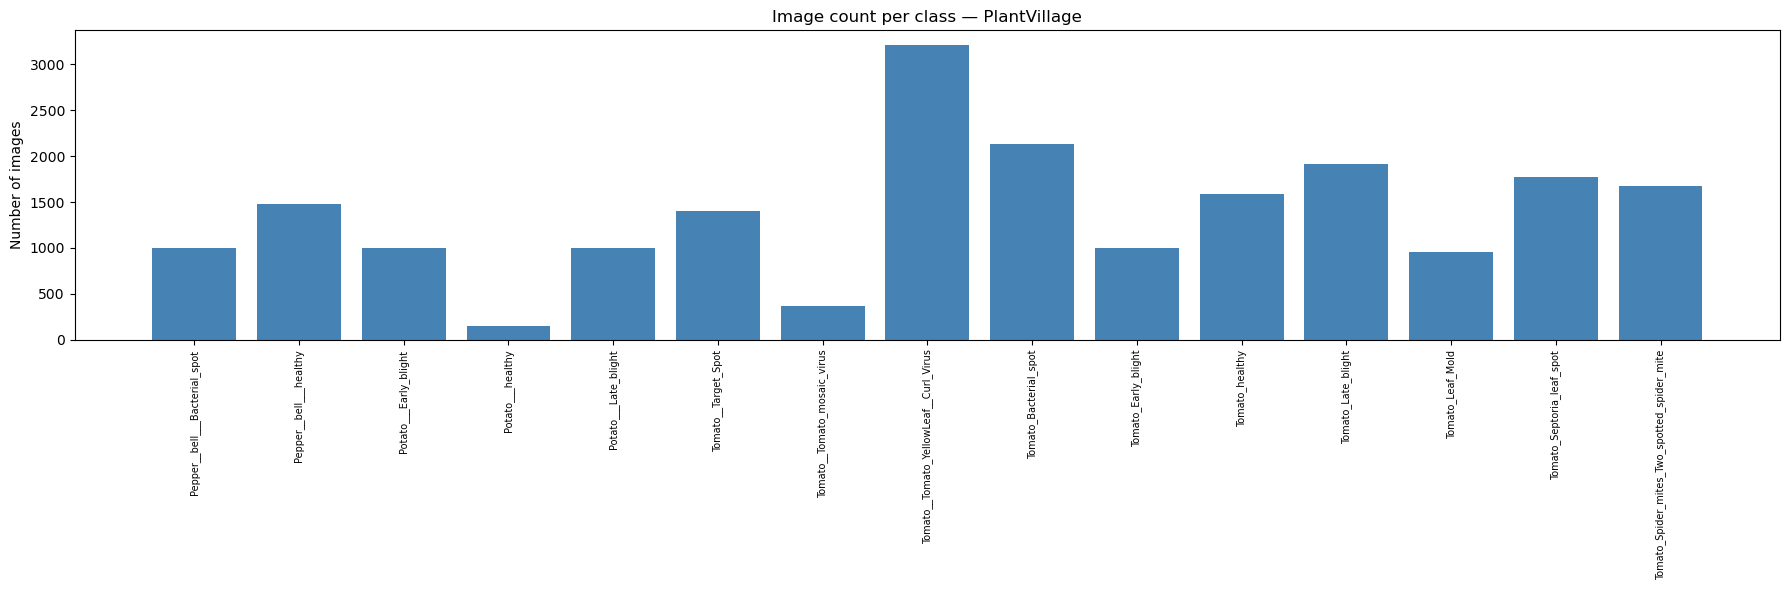

Saved → results/class_distribution.png


In [5]:
print("TOP 5 largest classes:")
print(df.nlargest(5, "count")[["class", "count"]].to_string(index=False))
print()
print("TOP 5 smallest classes:")
print(df.nsmallest(5, "count")[["class", "count"]].to_string(index=False))
print()
print(f"Max   : {df['count'].max()}")
print(f"Min   : {df['count'].min()}")
print(f"Mean  : {df['count'].mean():.0f}")
print(f"Imbalance ratio: {df['count'].max() / df['count'].min():.1f}x")

# Bar chart
plt.figure(figsize=(18, 6))
plt.bar(df["class"], df["count"], color="steelblue")
plt.xticks(rotation=90, fontsize=7)
plt.title("Image count per class — PlantVillage")
plt.ylabel("Number of images")
plt.tight_layout()
os.makedirs("../results", exist_ok=True)
plt.savefig("../results/class_distribution.png", dpi=150)
plt.show()
print("Saved → results/class_distribution.png")

## Check for Corrupted Images
This cell checks for corrupted images using extentions. .verify for PIL checks for corrupted or truncated images without fully decoding and loading the entire pixel data into memory

In [6]:
corrupted = []

for folder in sorted(DATA_DIR.iterdir()):
    if not folder.is_dir():
        continue
    for img_path in folder.iterdir():
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception as e:
            corrupted.append({"path": str(img_path), "error": str(e)})

print(f"Corrupted images found: {len(corrupted)}")
for c in corrupted:
    print(c)

Corrupted images found: 0


## Delete corrupted image
It deleted corrupted images if it contains any.

In [7]:
if len(corrupted) == 0:
    print("No corrupted images — nothing to delete.")
else:
    for c in corrupted:
        os.remove(c["path"])                          ## permanently deletes the images
        print(f"Deleted: {c['path']}")
    print(f"\nDeleted {len(corrupted)} corrupted files.")

No corrupted images — nothing to delete.


## Audit Image Sizes and Color Modes
It audit the image sizes and color modes taking 10 sample image from all classes and checks if there are any images that are NON-RGB

In [8]:
sizes = []
modes = []

for folder in sorted(DATA_DIR.iterdir()):
    if not folder.is_dir():
        continue
    sample = [
        p for p in folder.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ][:10]
    for img_path in sample:
        try:
            with Image.open(img_path) as img:
                sizes.append(img.size)
                modes.append(img.mode)
        except:
            pass

size_counts = Counter(sizes)
mode_counts = Counter(modes)

print("Most common image sizes:")
for size, count in size_counts.most_common(5):
    print(f"  {size[0]}x{size[1]} — {count} sampled images")

print("\nColour modes found:")
for mode, count in mode_counts.items():
    print(f"  {mode} — {count} sampled images")

non_rgb = {m: c for m, c in mode_counts.items() if m != "RGB"}
if non_rgb:
    print(f"\n Non-RGB modes found: {non_rgb}")
    print("   These will be auto-converted to RGB during the split (Cell 9 handles this).")
else:
    print("\n All sampled images are RGB.")

Most common image sizes:
  256x256 — 150 sampled images

Colour modes found:
  RGB — 150 sampled images

 All sampled images are RGB.


## Create train / val / test split
It splits the dataset into train, test, and val with class cap. You can adjust MAX_PER_CLASS to avoid these problems
 + if class A has 10000 images and class B has 200 images it helps the model to prevent biasness.
   - The fix: cap the amount of images to according to oneself and test the model.
 + Massive data sets require vast amount of resources and single bloated class can take long compared to clean class
   - So, allowing set amount of images takes less time
 + Out-Of-Memory and Storage Issues: datasets can to be too big and after already taking storage for uncleaned data, it also needs storage for     Train/test/split 
   - It fixes this problem by allowing only certain amount of images to be splited

If you dont want to apply this filter you can set MAX_PER_CLASS to 0 to allow all images.

It also skips empty folder if any

In [9]:
MAX_PER_CLASS = 1000

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

split_summary = []

for class_folder in sorted(DATA_DIR.iterdir()):
    if not class_folder.is_dir():
        continue

    class_name = class_folder.name
    all_images = [
        p for p in class_folder.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    if len(all_images) == 0:
        print(f"Skipping empty folder: {class_name}")
        continue

    random.shuffle(all_images)

    # Cap large classes
    if MAX_PER_CLASS and len(all_images) > MAX_PER_CLASS:
        all_images = all_images[:MAX_PER_CLASS]

    n       = len(all_images)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    splits = {
        "train" : all_images[:n_train],
        "val"   : all_images[n_train : n_train + n_val],
        "test"  : all_images[n_train + n_val:]
    }

    for split_name, files in splits.items():
        dest_dir = CLEAN_DIR / split_name / class_name
        dest_dir.mkdir(parents=True, exist_ok=True)
        for f in files:
            try:
                # Convert non-RGB images to RGB while copying
                with Image.open(f) as img:
                    rgb_img = img.convert("RGB")
                    rgb_img.save(dest_dir / (f.stem + ".jpg"), "JPEG")
            except Exception as e:
                print(f"  Skipped {f.name}: {e}")

    split_summary.append({
        "class" : class_name,
        "total" : n,
        "train" : len(splits["train"]),
        "val"   : len(splits["val"]),
        "test"  : len(splits["test"])
    })

    print(f"✓ {class_name:45s} total={n:4d}  "
          f"train={len(splits['train']):3d}  "
          f"val={len(splits['val']):3d}  "
          f"test={len(splits['test']):3d}")

summary_df = pd.DataFrame(split_summary)
summary_df.to_csv("../results/split_summary.csv", index=False)

print()
print(f"TOTALS — train: {summary_df['train'].sum()}  "
      f"val: {summary_df['val'].sum()}  "
      f"test: {summary_df['test'].sum()}")
print("Saved → results/split_summary.csv")

✓ Pepper__bell___Bacterial_spot                 total= 997  train=697  val=149  test=151
✓ Pepper__bell___healthy                        total=1000  train=700  val=150  test=150
Skipping empty folder: PlantVillage
✓ Potato___Early_blight                         total=1000  train=700  val=150  test=150
✓ Potato___healthy                              total= 152  train=106  val= 22  test= 24
✓ Potato___Late_blight                          total=1000  train=700  val=150  test=150
✓ Tomato__Target_Spot                           total=1000  train=700  val=150  test=150
✓ Tomato__Tomato_mosaic_virus                   total= 373  train=261  val= 55  test= 57
✓ Tomato__Tomato_YellowLeaf__Curl_Virus         total=1000  train=700  val=150  test=150
✓ Tomato_Bacterial_spot                         total=1000  train=700  val=150  test=150
✓ Tomato_Early_blight                           total=1000  train=700  val=150  test=150
✓ Tomato_healthy                                total=1000  train=700  val

## Save class names and Compute class weights
Weights in this helps to define the relative importance of to fix unfair data distribution while training model

In [10]:
train_dir    = CLEAN_DIR / "train"
class_names  = sorted([f.name for f in train_dir.iterdir() if f.is_dir()])
class_counts = np.array([
    len(list((train_dir / c).glob("*"))) for c in class_names
])

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(class_names)),
    y=np.repeat(np.arange(len(class_names)), class_counts)
)

class_weight_dict = dict(enumerate(weights))

os.makedirs("../models", exist_ok=True)
np.save("../models/class_names.npy", np.array(class_names))
np.save("../models/class_weights.npy", weights)

print(f"Number of classes: {len(class_names)}")
print()
print("Sample class weights:")
for i, name in enumerate(class_names[:5]):
    print(f"  {name:45s}  weight: {weights[i]:.3f}")
print("  ...")
print()
print("Saved -> models/class_names.npy")
print("Saved -> models/class_weights.npy")

Number of classes: 15

Sample class weights:
  Pepper__bell___Bacterial_spot                  weight: 0.902
  Pepper__bell___healthy                         weight: 0.898
  Potato___Early_blight                          weight: 0.898
  Potato___Late_blight                           weight: 0.898
  Potato___healthy                               weight: 5.931
  ...

Saved -> models/class_names.npy
Saved -> models/class_weights.npy


## Visual Verificaiton
This shows images to see if all training sets are taken randomly.

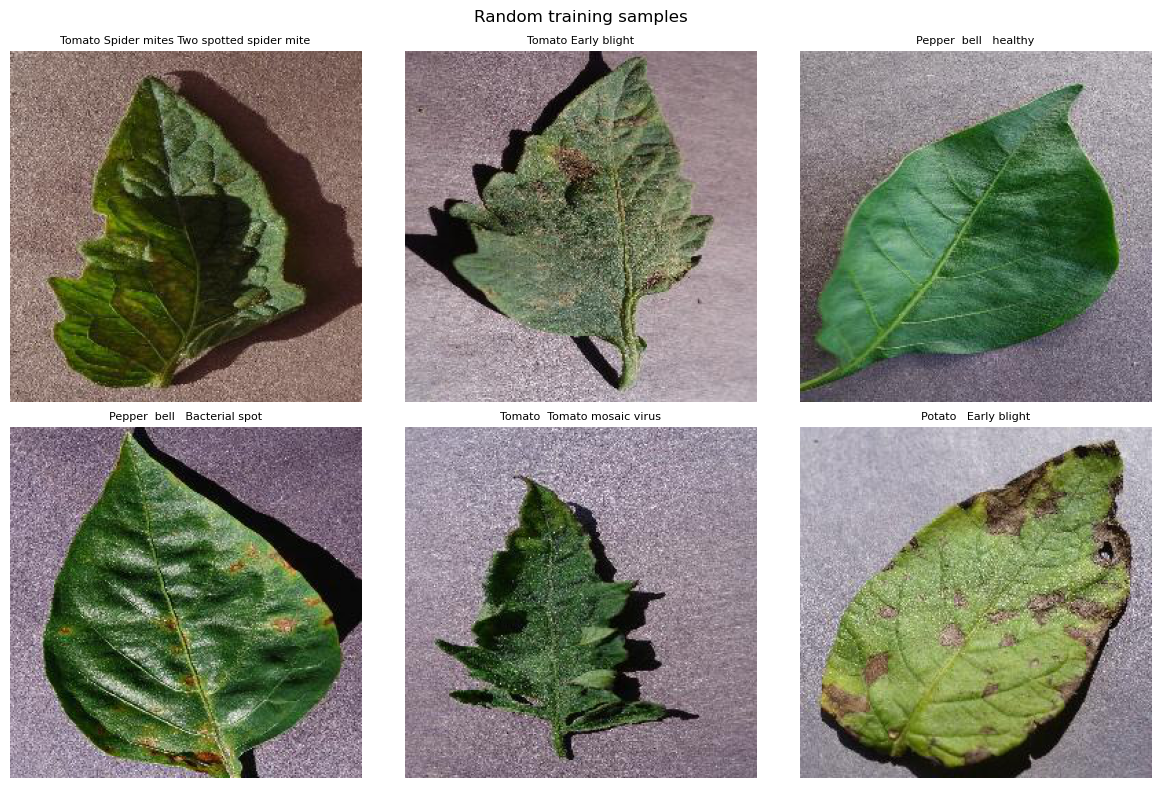

Saved -> results/sample_training_images.png


In [11]:
all_class_dirs = sorted(train_dir.iterdir())
sample_classes = random.sample(all_class_dirs, min(6, len(all_class_dirs)))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, cls in zip(axes.flatten(), sample_classes):
    img_file = random.choice(list(cls.iterdir()))
    img = Image.open(img_file).convert("RGB")
    ax.imshow(img)
    ax.set_title(cls.name.replace("_", " "), fontsize=8)
    ax.axis("off")

plt.suptitle("Random training samples", fontsize=12)
plt.tight_layout()
plt.savefig("../results/sample_training_images.png", dpi=150)
plt.show()
print("Saved -> results/sample_training_images.png")

## Final Summary
This print the classes it split along with number of images.

In [12]:
print("Final split summary")
for split in ["train", "val", "test"]:
    split_path = CLEAN_DIR / split
    classes    = list(split_path.iterdir())
    total      = sum(len(list(c.iterdir())) for c in classes)
    print(f"  {split:5s} — {len(classes):2d} classes, {total:6d} images")

print()
print("   Data cleaning complete.")
print("   Next step → notebooks/02_data_pipeline.ipynb")
print("   Point DATA_DIR at: ../data/PlantVillage_split/train")

Final split summary
  train — 15 classes,   9430 images
  val   — 15 classes,   2018 images
  test  — 15 classes,   2026 images

   Data cleaning complete.
   Next step → notebooks/02_data_pipeline.ipynb
   Point DATA_DIR at: ../data/PlantVillage_split/train
